In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-dataset/netflix_titles.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
netflix = pd.read_csv("/kaggle/input/netflix-dataset/netflix_titles.csv")

In [4]:
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [5]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### **Count the number of occurrences of each content type ie movies and series**

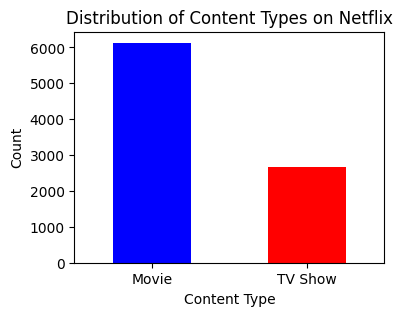

In [7]:
content_type_counts = netflix['type'].value_counts()

plt.figure(figsize=(4, 3))
content_type_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### **Count the number of occurrences of each rating**

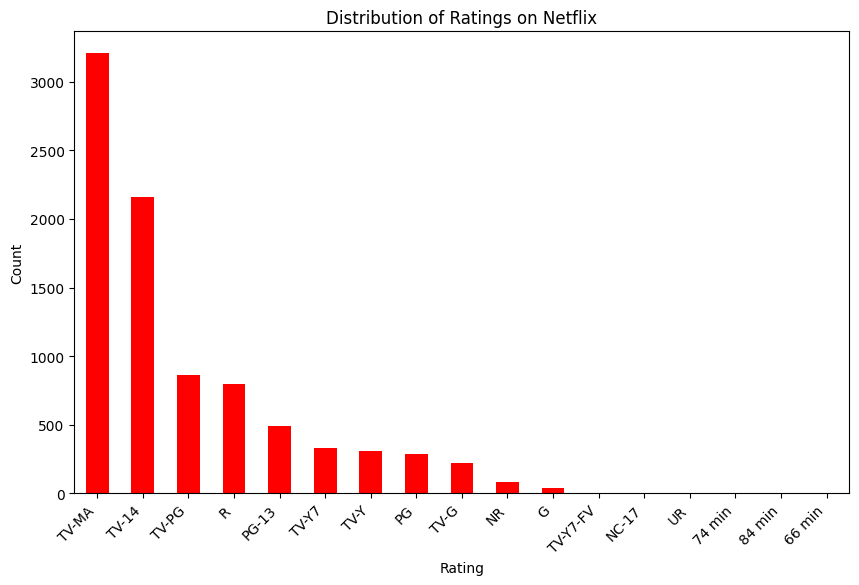

In [8]:
rating_counts = netflix['rating'].value_counts()


plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar', color='red')
plt.title('Distribution of Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

### **Grouping the data by release year and counting the number of entries for each year**

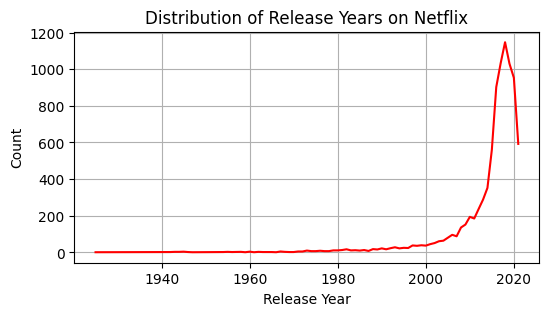

In [9]:
release_year_counts = netflix['release_year'].value_counts().sort_index()

plt.figure(figsize=(6, 3))
release_year_counts.plot(kind='line', color='red')
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### **Counting the number of occurrences of each country**

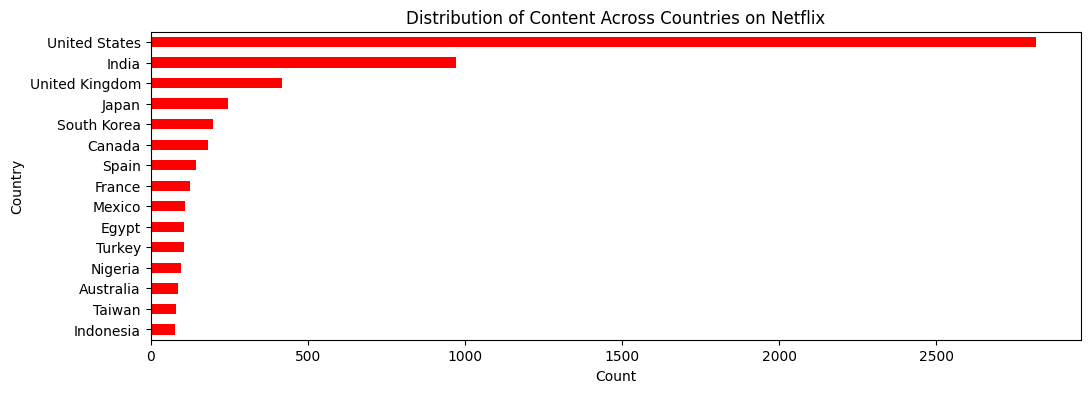

In [10]:
country_counts = netflix['country'].value_counts().head(15)  # Displaying the top 15 countries


plt.figure(figsize=(12, 4))
country_counts.plot(kind='barh', color='red')
plt.title('Distribution of Content Across Countries on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')
plt.gca().invert_yaxis()  
plt.show()

### **Grouping the data by director and calculating the average rating for each director**

In [11]:
# Mapping ratings to numerical values
rating_map = {
    'TV-Y': 0, 'TV-Y7': 7, 'TV-Y7-FV': 7, 'TV-G': 7, 'TV-PG': 12, 
    'TV-14': 14, 'TV-MA': 18, 'R': 18, 'NC-17': 18, 'NR': None
}

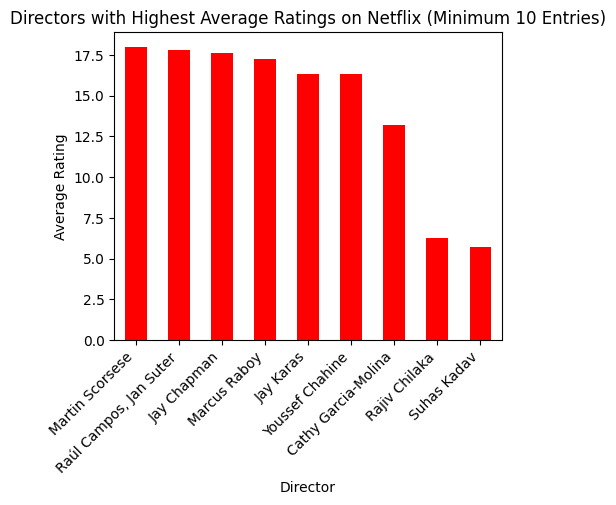

In [12]:
netflix['rating_numeric'] = netflix['rating'].map(rating_map)

# Grouping the data by director and calculating the average rating for each director
director_ratings = netflix.groupby('director')['rating_numeric'].agg(['mean', 'count'])
director_ratings = director_ratings[director_ratings['count'] >= 10]  # Filter directors with at least 10 entries
director_ratings = director_ratings.sort_values(by='mean', ascending=False).head(15)  # Displaying top 15 directors by average rating

plt.figure(figsize=(5, 4))
director_ratings['mean'].plot(kind='bar', color='red')
plt.title('Directors with Highest Average Ratings on Netflix (Minimum 10 Entries)')
plt.xlabel('Director')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()


### **Splitting the genres listed in each entry and counting their occurrences**

In [13]:
from collections import Counter

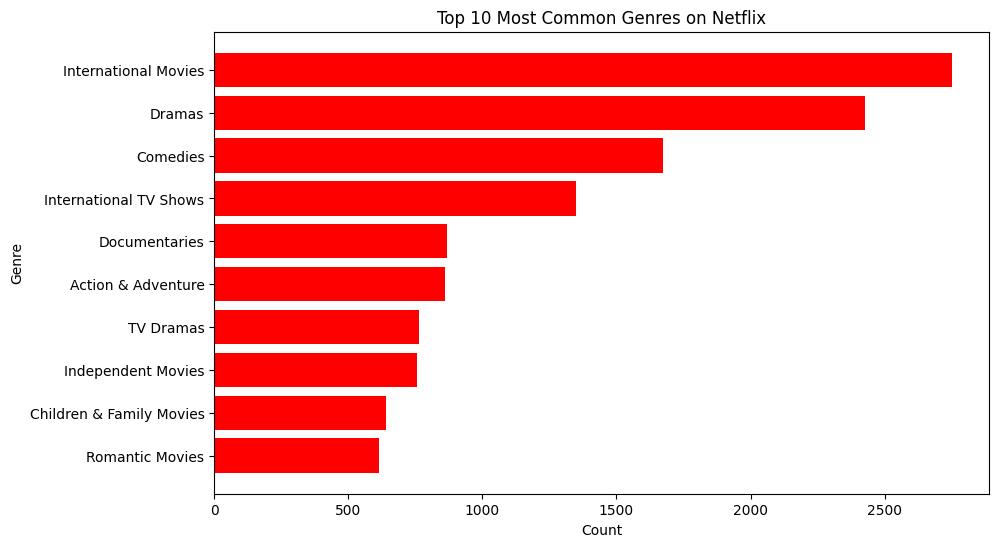

In [14]:
genres = netflix['listed_in'].apply(lambda x: x.split(', '))
genre_counts = Counter(genre for sublist in genres for genre in sublist)

# Selecting the top 10 most common genres
top_genres = dict(genre_counts.most_common(10))

plt.figure(figsize=(10, 6))
plt.barh(list(top_genres.keys()), list(top_genres.values()), color='red')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()  
plt.show()


### **Trend of netflix adding the shows**

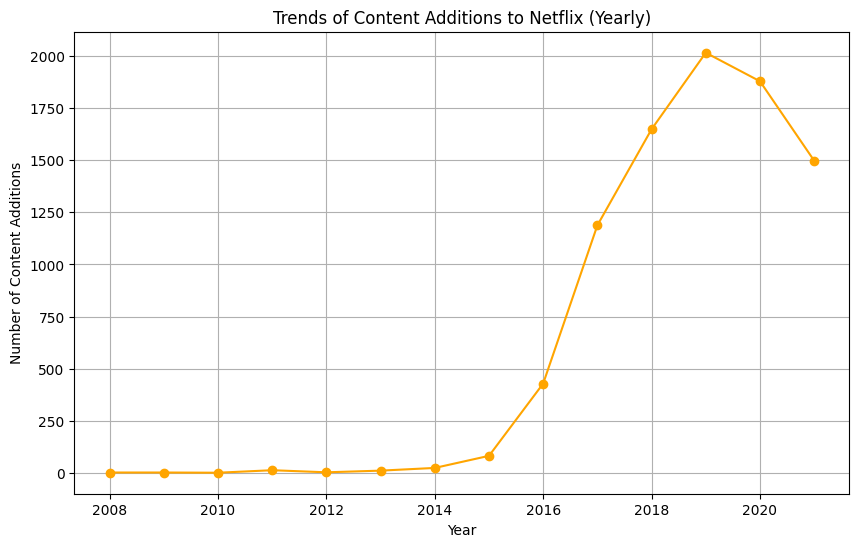

In [15]:
netflix['date_added'] = netflix['date_added'].str.strip()

netflix['date_added'] = pd.to_datetime(netflix['date_added'], format='%B %d, %Y')

netflix['year_added'] = netflix['date_added'].dt.year

content_additions_by_year = netflix['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
content_additions_by_year.plot(kind='line', marker='o', color='orange')
plt.title('Trends of Content Additions to Netflix (Yearly)')
plt.xlabel('Year')
plt.ylabel('Number of Content Additions')
plt.grid(True)
plt.show()


### **USING ARIMA MODEL**
ARIMA, which stands for Autoregressive Integrated Moving Average, is a popular and powerful time series analysis and forecasting method. It's a combination of three components: autoregression (AR), differencing (I), and moving average (MA). ARIMA models are widely used in various fields such as finance, economics, epidemiology, and climate science for analyzing and predicting time-dependent data.

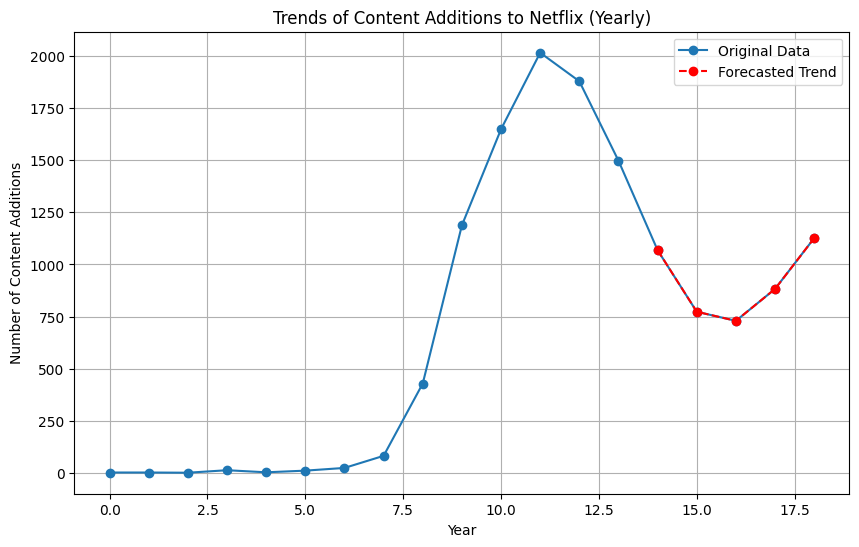

In [16]:
from statsmodels.tsa.arima.model import ARIMA

content_additions_by_year = content_additions_by_year.reset_index(drop=True)

# Define the ARIMA model
model = ARIMA(content_additions_by_year, order=(5, 1, 0))  
model_fit = model.fit()

# Forecast future trend for 5 years
future_forecast_values = model_fit.forecast(steps=5) 

forecast_years = range(content_additions_by_year.index[-1] + 1, content_additions_by_year.index[-1] + 6)

combined_index = content_additions_by_year.index.tolist() + list(forecast_years)
combined_data = content_additions_by_year.tolist() + future_forecast_values.tolist()

plt.figure(figsize=(10, 6))
plt.plot(combined_index, combined_data, label='Original Data', marker='o')
plt.plot(forecast_years, future_forecast_values, label='Forecasted Trend', linestyle='dashed', color='red', marker='o')
plt.title('Trends of Content Additions to Netflix (Yearly)')
plt.xlabel('Year')
plt.ylabel('Number of Content Additions')
plt.legend()
plt.grid(True)
plt.show()
